# 🛡️ Safe RAG: 금융 문서 임베딩 벡터 역전공격 방어 실험

## 실험 개요
RAG(Retrieval-Augmented Generation) 시스템의 벡터 DB에는 실제 금융 문서의 임베딩이 저장된다.
**Vec2Text** 같은 역전공격(embedding inversion attack)은 이 벡터만으로 원문 텍스트를 상당 수준 복원할 수 있어,
고객 PII(개인식별정보) 유출 위험이 존재한다.

이 노트북은 다음 흐름으로 방어 전략의 효과를 실험한다:

```
금융 문서 생성 → 임베딩 → Vec2Text 역전공격 → PCA/PII 방어 → 재공격 → 트레이드오프 분석
```

| 단계 | 내용 |
|------|------|
| Step 1 | 금융 PII 데이터셋 생성 + 임베딩 + FAISS 인덱스 |
| Step 2 | 원본 벡터 역전공격 (공격 기준선 측정) |
| Step 3 | 정규화 벡터 역전공격 (단순 정규화의 방어 효과 확인) |
| Step 4 | PCA 방어 벡터 역전공격 + RAG 트레이드오프 분석 |
| Step 5 | PII-aware 억제 + PCA 복합 방어 |
| Step 6 | 최적 PCA n_components 탐색 |
| Bonus | 공용 PCA 벡터 배포 Feasibility Check |

## Step 1. 금융 문서 임베딩 벡터 생성

### 목적
공격 실험에 사용할 현실적인 금융 문서 데이터셋을 준비한다.
vec2text 모델이 **영어로 학습**되어 있어, 한국어 문서를 그대로 쓰면 공격 효과가 과소평가된다.
따라서 실제 금융권 문서와 유사한 **영문 PII 포함 문서**를 GPT-4o로 생성한다.

### 환경 설정

### 1-0. 환경 설정

작업 디렉토리 확인, OpenAI API 키 로드, 의존 패키지 설치를 순서대로 수행한다.
`.env` 파일에 `OPENAI_API_KEY`가 설정되어 있어야 하며, GPU 환경(Colab A100)을 권장한다.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [1]:
import os
import sys

# 루트 디렉토리 설정 (Colab/Local)
# Colab: /content/drive/MyDrive/Safe_RAG
# Local: ./Safe_RAG 또는 절대경로
try:
    # Colab 환경 감지
    import google.colab
    ROOT_DIR = "/content/drive/MyDrive/Safe_RAG"
except ImportError:
    # 로컬 환경
    ROOT_DIR = r"C:\Users\jjh63\Safe_RAG"

print(f"ROOT_DIR: {ROOT_DIR}")
print(f"파일들이 존재하는지 확인:")
print(f"  - .env: {os.path.exists(os.path.join(ROOT_DIR, '.env'))}")
print(f"  - colab_requirements.txt: {os.path.exists(os.path.join(ROOT_DIR, 'colab_requirements.txt'))}")
print(f"  - output: {os.path.exists(os.path.join(ROOT_DIR, 'output'))}")

ROOT_DIR: C:\Users\jjh63\Safe_RAG
파일들이 존재하는지 확인:
  - .env: True
  - colab_requirements.txt: True
  - output: True


In [2]:
from dotenv import load_dotenv
import os

load_dotenv("/content/drive/MyDrive/Safe_RAG/.env")
api_key = os.getenv("OPENAI_API_KEY")
print(api_key[:10], "...")

sk-proj-5v ...


In [7]:
! cd

c:\Users\jjh63\Safe_RAG


In [18]:
! pip install progressbar

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Running setup.py install for progressbar: started
  Running setup.py install for progressbar: finished with status 'done'


  DEPRECATION: progressbar is being installed using the legacy 'setup.py install' method, because it does not have a 'pyproject.toml' and the 'wheel' package is not installed. pip 23.1 will enforce this behaviour change. A possible replacement is to enable the '--use-pep517' option. Discussion can be found at https://github.com/pypa/pip/issues/8559

[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
! pip install -r "{ROOT_DIR}/colab_requirements.txt" --quiet --progress-bar on

^C


### 1-2. 문서 로드 및 청크 분할

**목적**: 생성된 금융 문서를 RAG에 적합한 크기로 분할한다.

| 파라미터 | 값 | 이유 |
|----------|-----|------|
| chunk_size | 512 토큰 | Ada-002의 최적 입력 길이 |
| chunk_overlap | 64 토큰 | 문장 경계 정보 손실 방지 |

**인사이트**: 청크가 너무 크면 임베딩이 희석되고, 너무 작으면 맥락이 끊긴다.
512/64 설정은 금융 문서의 단락 구조에 맞게 선택했다.

In [4]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
import json
from pathlib import Path
from langchain_core.documents import Document

# output 폴더에서 financial_pii_dataset.jsonl 읽기
output_path = Path(ROOT_DIR) / "output" / "financial_pii_dataset.jsonl"

if not output_path.exists():
    print(f"Error: {output_path}를 찾을 수 없습니다.")
    print("먼저 llm_synthetic_financial_pii_generator.py를 실행하여 데이터를 생성하세요.")
else:
    # JSONL 파일에서 문서 로드
    documents = []
    with open(output_path, 'r', encoding='utf-8') as f:
        for line in f:
            record = json.loads(line)
            # LangChain Document 형식으로 변환
            doc = Document(
                page_content=record['text'],
                metadata={
                    'doc_id': record['doc_id'],
                    'doc_type': record['doc_type'],
                    'model': record['model']
                }
            )
            documents.append(doc)

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=512,
        chunk_overlap=64,
        separators=["\n\n", "\n", ".", " "]
    )
    chunks = splitter.split_documents(documents)
    print(f"총 청크 수: {len(chunks)}")
    print(f"로드된 문서 수: {len(documents)}")

총 청크 수: 4640
로드된 문서 수: 1000


### 1-3. 임베딩 생성 및 FAISS 인덱스 구축

**목적**: 각 청크를 `text-embedding-ada-002`로 1536차원 벡터로 변환하고,
FAISS `IndexFlatIP`(내적 기반 유사도)로 저장한다.

- `embeddings_unsafe_raw.npy`: 원본 벡터 (공격 실험용)
- `faiss_unsafe.index`: 정규화 벡터 인덱스 (RAG 검색용)

**인사이트**: FAISS는 내부 저장 시 L2 정규화를 적용하므로,
원본 벡터와 FAISS 내부 벡터는 크기(magnitude)만 다르고 방향은 동일하다.
역전공격 실험에서는 이 두 버전을 분리해 비교한다.

In [5]:
from openai import OpenAI
client = OpenAI()
for m in client.models.list():
    print(m.id)


text-embedding-ada-002
text-embedding-3-small
gpt-4o-mini
omni-moderation-latest
o4-mini
gpt-4.1-mini


In [6]:
import numpy as np
import faiss
from tqdm import tqdm
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()
client = OpenAI()

def get_embedding(text: str) -> np.ndarray:
    response = client.embeddings.create(
        model="text-embedding-ada-002",
        input=text
    )
    return np.array(response.data[0].embedding, dtype=np.float32)

def build_and_save_index(chunks, index_path: str, raw_path: str):
    embeddings_list = []
    for chunk in tqdm(chunks, desc=f"임베딩 생성"):
        embeddings_list.append(get_embedding(chunk.page_content))

    embeddings_raw = np.vstack(embeddings_list)

    np.save(raw_path, embeddings_raw)
    print(f"원본 벡터 저장: {raw_path} | shape: {embeddings_raw.shape}")

    embeddings_norm = embeddings_raw.copy()
    faiss.normalize_L2(embeddings_norm)
    index = faiss.IndexFlatIP(1536)
    index.add(embeddings_norm)
    faiss.write_index(index, index_path)
    print(f"FAISS 인덱스 저장: {index_path} | {index.ntotal}개 벡터")

    return embeddings_raw

embeddings_raw = build_and_save_index(
      chunks,
      index_path=os.path.join(ROOT_DIR, "faiss_unsafe.index"),
      raw_path=os.path.join(ROOT_DIR, "embeddings_unsafe_raw.npy")
  )

임베딩 생성:   0%|          | 3/4640 [00:03<1:32:50,  1.20s/it]


KeyboardInterrupt: 

### 1-4. RAG 기본 성능 측정 (Recall@K)

**목적**: 방어 적용 전 기준 RAG 성능을 먼저 측정한다.
이후 방어를 적용했을 때 성능 저하를 이 값과 비교한다.

**Recall@K**: 특정 청크를 쿼리로 넣었을 때 동일 청크가 상위 K개 결과 안에 나오는 비율.
이상적인 RAG 인덱스라면 Recall@5 = 100%가 되어야 한다.

In [7]:
import numpy as np
import faiss
from tqdm import tqdm
from dotenv import load_dotenv
from openai import OpenAI

def get_embedding(text: str) -> np.ndarray:
    response = client.embeddings.create(
        model="text-embedding-ada-002",
        input=text
    )
    return np.array(response.data[0].embedding, dtype=np.float32)

In [8]:
def recall_at_k(index_path, chunks, k=5, n_eval=20):
    index = faiss.read_index(index_path)
    hits = 0
    for i in range(min(n_eval, len(chunks))):
        vec = get_embedding(chunks[i].page_content).reshape(1, -1)
        faiss.normalize_L2(vec)
        _, indices = index.search(vec, k)
        if i in indices[0]:
            hits += 1
    score = hits / min(n_eval, len(chunks))
    print(f"Recall@{k} ({index_path}): {score:.2f}")
    return score

recall_at_k(os.path.join(ROOT_DIR, "faiss_unsafe.index"), chunks)
# 목표: 0.90 이상

Recall@5 (C:\Users\jjh63\Safe_RAG\faiss_unsafe.index): 1.00


1.0

### 1-5. FAISS 인덱스에서 정규화 벡터 추출

**목적**: FAISS에 저장된 L2 정규화 벡터를 numpy 배열로 복원한다.
`index.reconstruct_n()`은 FAISS 인덱스 내부의 벡터를 직접 읽어오는 함수다.

**인사이트**: 이 벡터는 원본과 방향이 동일하지만 크기가 1로 고정되어 있다.
Step 3에서 '정규화만으로 방어가 되는가'를 검증하기 위해 별도로 추출한다.

In [9]:
import faiss
import numpy as np

index = faiss.read_index(os.path.join(ROOT_DIR, "faiss_unsafe.index"))
n = index.ntotal
dim = index.d

embeddings_norm = np.zeros((n, dim), dtype=np.float32)
index.reconstruct_n(0, n, embeddings_norm)

print(f"추출된 정규화 벡터: {embeddings_norm.shape}")

추출된 정규화 벡터: (4640, 1536)


### 1-6. 임베딩 유틸 함수 재정의

이후 단계에서 새로운 텍스트(예: 쿼리, PII 샘플)를 임베딩할 때 사용하는 공통 함수.
모델은 전 단계와 동일한 `text-embedding-ada-002`를 유지한다.

In [10]:
from openai import OpenAI
import numpy as np

client = OpenAI()  # OPENAI_API_KEY 환경변수 필요

def get_embedding(text: str) -> np.ndarray:
    response = client.embeddings.create(
        model="text-embedding-ada-002",
        input=text
    )
    return np.array(response.data[0].embedding, dtype=np.float32)

### 1-7. PCA 방어 벡터 생성 (1차 시도, n=128)

**목적**: 원본 1536차원 벡터를 128차원으로 압축 후 역투영(reconstruct)한다.
이 과정에서 하위 주성분 정보가 손실되며, 역전공격 모델이 복원에 필요한 세부 패턴이 제거된다.

**원리**:
```
원본 (1536d) → PCA 압축 (128d) → 역투영 (1536d) → 방어 벡터
```
차원은 원본과 동일하게 유지되므로 FAISS 인덱스 구조를 그대로 사용할 수 있다.

**인사이트**: n=128은 1536의 약 8% 수준으로, 상당한 정보 손실이 발생한다.
방어력은 높겠지만 RAG 검색 품질 저하도 클 수 있다. Step 4에서 검증한다.

In [11]:
from sklearn.decomposition import PCA
import torch
import numpy as np

embeddings_raw = np.load(os.path.join(ROOT_DIR, "embeddings_unsafe_raw.npy"))
print(f"원본 벡터 shape: {embeddings_raw.shape}")

embeddings_matrix = embeddings_raw.astype(np.float32)
n_samples, n_features = embeddings_matrix.shape

n_components = min(128, n_samples - 1)
print(f"PCA 설정: {n_features}d → {n_components}d → {n_features}d")

pca = PCA(n_components=n_components, svd_solver='full')
pca.fit(embeddings_matrix)

compressed    = pca.transform(embeddings_matrix)
reconstructed = pca.inverse_transform(compressed).astype(np.float32)

np.save(os.path.join(ROOT_DIR, "embeddings_defense_pca.npy"), reconstructed)

retained = pca.explained_variance_ratio_.sum()
print(f"PCA 방어 벡터 저장 완료")
print(f"보존된 분산: {retained:.1%}")

원본 벡터 shape: (4640, 1536)
PCA 설정: 1536d → 128d → 1536d
PCA 방어 벡터 저장 완료
보존된 분산: 77.5%


## Step 2. 원본 벡터로 Vec2Text 역전공격

### 목적
`text-embedding-ada-002`가 생성한 **원본 1536차원 벡터**에 직접 Vec2Text를 적용한다.
이 결과가 **공격 기준선(baseline)**이 된다.

### 측정 지표
- **ROUGE-1 F1**: 복원된 텍스트와 원문의 단어 겹침 비율. 높을수록 공격 성공.

### 예상
정보 손실 없는 원본 벡터이므로 ROUGE가 가장 높게 나올 것.

In [31]:
import transformers, accelerate
print("transformers:", transformers.__version__)
print("accelerate:", accelerate.__version__)


transformers: 4.44.2
accelerate: 0.34.2


In [37]:
! pip install --upgrade pip
! pip install resource

     ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
     ------------------------ --------------- 1.1/1.8 MB 23.5 MB/s eta 0:00:01
     ---------------------------------------- 1.8/1.8 MB 23.1 MB/s eta 0:00:00


ERROR: To modify pip, please run the following command:
C:\Users\jjh63\Safe_RAG\safeRag\Scripts\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import torch

# meta device가 default로 잡혀 있으면 실제 디바이스로 복구
device = "cuda" if torch.cuda.is_available() else "cpu"

# if torch.get_default_device().type == "meta":
#     print(f"⚠️ default device가 meta로 설정되어 있습니다 → {device}로 복구")
torch.set_default_device(device)
# print(f"✅ default device: {torch.get_default_device()}")

# vec2text 로드 (디바이스 컨텍스트 안에서 안전하게)
import vec2text
# with torch.device(device):
corrector = vec2text.load_pretrained_corrector("text-embedding-ada-002")

print("✅ corrector 로드 완료")

c:\Users\jjh63\Safe_RAG\safeRag\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\jjh63\Safe_RAG\safeRag\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


✅ corrector 로드 완료


In [13]:
import vec2text
import torch
import numpy as np
from tqdm import tqdm
from rouge_score import rouge_scorer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}")

# corrector = vec2text.load_pretrained_corrector("text-embedding-ada-002")

embeddings_raw = np.load(os.path.join(ROOT_DIR, "embeddings_unsafe_raw.npy"))
print(f"원본 벡터 shape: {embeddings_raw.shape}")

sample_vecs = torch.tensor(embeddings_raw[:10]).to(device)
originals = [chunks[i].page_content for i in range(10)]
scorer = rouge_scorer.RougeScorer(['rouge1'], use_stemmer=False)

recovered = []
scores_raw = []

for i in tqdm(range(10), desc="원본 벡터 역전공격"):
    vec = sample_vecs[i:i+1]
    result = vec2text.invert_embeddings(
        embeddings=vec,
        corrector=corrector,
        num_steps=10,
        sequence_beam_width=4,
    )
    rec = result[0]
    recovered.append(rec)

    score = scorer.score(originals[i], rec)
    rouge = score['rouge1'].fmeasure
    scores_raw.append(rouge)

    print(f"\n[청크 {i}] ROUGE-1: {rouge:.3f}")
    print(f"  원본: {originals[i][:60]}...")
    print(f"  복원: {rec[:60]}...")

print("\n" + "="*50)
print(f"평균 ROUGE-1 (원본 벡터 기준): {np.mean(scores_raw):.3f}")
print(f"최고: {max(scores_raw):.3f} | 최저: {min(scores_raw):.3f}")
print("="*50)

사용 디바이스: cuda
원본 벡터 shape: (4640, 1536)


원본 벡터 역전공격:  10%|█         | 1/10 [00:51<07:43, 51.50s/it]


[청크 0] ROUGE-1: 0.094
  원본: Philip Martin  
08455 Meagan Groves  
Deborahshire, MH 37582...
  복원: Martin Phillips Bank                                        ...


원본 벡터 역전공격:  20%|██        | 2/10 [01:42<06:50, 51.26s/it]


[청크 1] ROUGE-1: 0.530
  원본: Please process the closure at your earliest convenience and ...
  복원: Please proceed at your earliest convenience and transfer the...


...


[청크 7] ROUGE-1: 0.491
  원본: Subject: Urgent: Disputed International Wire Transfer Notifi...
  복원: Dear Danny, Our company has sent you an urgent notification ...


원본 벡터 역전공격:  90%|█████████ | 9/10 [06:53<00:45, 45.92s/it]


[청크 8] ROUGE-1: 0.932
  원본: Because you have not previously authorized this transaction,...
  복원: Because you have not previously authorized this transaction,...


원본 벡터 역전공격: 100%|██████████| 10/10 [07:29<00:00, 44.98s/it]


[청크 9] ROUGE-1: 0.537
  원본: Please contact our Fraud Department as soon as possible at +...
  복원: Please contact our Fraud Department promptly at +1-855-731-7...

평균 ROUGE-1 (원본 벡터 기준): 0.523
최고: 0.932 | 최저: 0.094


## Step 3. 정규화 벡터로 Vec2Text 역전공격

### 목적
FAISS는 내부적으로 벡터를 L2 정규화한다. 정규화 자체가 방어 효과를 갖는지 확인한다.

### 인사이트 (가설)
정규화는 벡터의 **방향**은 유지하고 크기만 제거하므로,
의미 정보는 그대로 남아 있어 방어 효과가 거의 없을 것으로 예상한다.
→ 만약 ROUGE가 원본과 비슷하게 나온다면, **정규화만으로는 충분하지 않음**을 의미.

In [14]:
import vec2text
import torch
import faiss
import numpy as np
from tqdm import tqdm
from rouge_score import rouge_scorer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}")

corrector = vec2text.load_pretrained_corrector("text-embedding-ada-002")

index = faiss.read_index(os.path.join(ROOT_DIR, "faiss_unsafe.index"))
n = index.ntotal
dim = index.d
embeddings_norm = np.zeros((n, dim), dtype=np.float32)
index.reconstruct_n(0, n, embeddings_norm)

sample_vecs = torch.tensor(embeddings_norm[:10]).to(device)
originals = [chunks[i].page_content for i in range(10)]
scorer = rouge_scorer.RougeScorer(['rouge1'], use_stemmer=False)

recovered = []
scores_norm = []

for i in tqdm(range(10), desc="역전공격 진행"):
    vec = sample_vecs[i:i+1]
    result = vec2text.invert_embeddings(
        embeddings=vec,
        corrector=corrector,
        num_steps=10,
        sequence_beam_width=0,
    )
    rec = result[0]
    recovered.append(rec)

    score = scorer.score(originals[i], rec)
    rouge = score['rouge1'].fmeasure
    scores_norm.append(rouge)

    print(f"\n[청크 {i}] ROUGE-1: {rouge:.3f}")
    print(f"  원본: {originals[i][:60]}...")
    print(f"  복원: {rec[:60]}...")

print("\n" + "="*50)
print(f"평균 ROUGE-1 (Unsafe 베이스라인): {np.mean(scores_norm):.3f}")
print(f"최고: {max(scores_norm):.3f} | 최저: {min(scores_norm):.3f}")
print("="*50)
print("→ 이 숫자가 높을수록 역전공격 성공, 낮을수록 자체 방어력 있음")

사용 디바이스: cuda


역전공격 진행:  10%|█         | 1/10 [00:30<04:37, 30.83s/it]


[청크 0] ROUGE-1: 0.091
  원본: Philip Martin  
08455 Meagan Groves  
Deborahshire, MH 37582...
  복원: Martin Philips Bank, Countryside Bank, Capital One, Branch  ...


역전공격 진행:  20%|██        | 2/10 [01:00<04:00, 30.06s/it]


[청크 1] ROUGE-1: 0.382
  원본: Please process the closure at your earliest convenience and ...
  복원: Please proceed to the earliest possible disposal of the fund...


...


[청크 7] ROUGE-1: 0.184
  원본: Subject: Urgent: Disputed International Wire Transfer Notifi...
  복원: Subject: âWe Need to Ensure Your Account is Deferred to a Gl...


역전공격 진행:  90%|█████████ | 9/10 [03:32<00:23, 23.26s/it]


[청크 8] ROUGE-1: 0.930
  원본: Because you have not previously authorized this transaction,...
  복원: Because you have not previously authorized this transaction,...


역전공격 진행: 100%|██████████| 10/10 [03:52<00:00, 23.28s/it]


[청크 9] ROUGE-1: 0.603
  원본: Please contact our Fraud Department as soon as possible at +...
  복원: Please notify our Fraud Department as soon as possible at +1...

평균 ROUGE-1 (Unsafe 베이스라인): 0.497
최고: 0.930 | 최저: 0.091
→ 이 숫자가 높을수록 역전공격 성공, 낮을수록 자체 방어력 있음


## Step 4-A. PCA 방어 벡터의 역전공격 방어 성능 측정

### 목적
128차원으로 압축 후 역투영(reconstruct)한 PCA 방어 벡터가 Vec2Text 공격을 얼마나 막는지 측정한다.

### 원리
PCA 재구성은 하위 주성분(노이즈 성분)을 버리는 효과가 있어,
역전공격 모델이 의존하는 세밀한 텍스트 패턴 정보가 손상된다.

### 인사이트 (가설)
압축률이 높을수록 (n_components가 작을수록) 방어력은 강해지지만,
RAG 검색 품질도 함께 저하되는 **트레이드오프**가 존재할 것.

In [16]:
import vec2text
import torch
import numpy as np
from tqdm import tqdm
from rouge_score import rouge_scorer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}")

corrector = vec2text.load_pretrained_corrector("text-embedding-ada-002")

embeddings_pca = np.load(os.path.join(ROOT_DIR, "embeddings_defense_pca.npy"))
print(f"PCA 방어 벡터 shape: {embeddings_pca.shape}")

sample_vecs = torch.tensor(embeddings_pca[:10]).to(device)
originals = [chunks[i].page_content for i in range(10)]
scorer = rouge_scorer.RougeScorer(['rouge1'], use_stemmer=False)

recovered = []
scores_pca = []

for i in tqdm(range(10), desc="PCA 방어 벡터 역전공격"):
    vec = sample_vecs[i:i+1]
    result = vec2text.invert_embeddings(
        embeddings=vec,
        corrector=corrector,
        num_steps=10,
        sequence_beam_width=0,
    )
    rec = result[0]
    recovered.append(rec)

    score = scorer.score(originals[i], rec)
    rouge = score['rouge1'].fmeasure
    scores_pca.append(rouge)

    print(f"\n[청크 {i}] ROUGE-1: {rouge:.3f}")
    print(f"  원본: {originals[i][:60]}...")
    print(f"  복원: {rec[:60]}...")

print("\n" + "="*50)
print(f"평균 ROUGE-1 (PCA 방어 벡터): {np.mean(scores_pca):.3f}")
print(f"최고: {max(scores_pca):.3f} | 최저: {min(scores_pca):.3f}")
print("="*50)

사용 디바이스: cuda
PCA 방어 벡터 shape: (4640, 1536)


PCA 방어 벡터 역전공격:  10%|█         | 1/10 [00:33<04:58, 33.19s/it]


[청크 0] ROUGE-1: 0.466
  원본: Philip Martin  
08455 Meagan Groves  
Deborahshire, MH 37582...
  복원: Martin Phillips Bank, FSB.  April 27, 2017  Dear Sir, I am w...


PCA 방어 벡터 역전공격:  20%|██        | 2/10 [00:59<03:50, 28.87s/it]


[청크 1] ROUGE-1: 0.466
  원본: Please process the closure at your earliest convenience and ...
  복원: Please proceed to the following to close your account. The r...


...


[청크 7] ROUGE-1: 0.327
  원본: Subject: Urgent: Disputed International Wire Transfer Notifi...
  복원: Dear Gary, We sent you the following notice regarding a rece...


PCA 방어 벡터 역전공격:  90%|█████████ | 9/10 [03:30<00:22, 22.86s/it]


[청크 8] ROUGE-1: 0.511
  원본: Because you have not previously authorized this transaction,...
  복원: We recognize that you did not authorize this transaction. To...


PCA 방어 벡터 역전공격: 100%|██████████| 10/10 [03:54<00:00, 23.42s/it]


[청크 9] ROUGE-1: 0.432
  원본: Please contact our Fraud Department as soon as possible at +...
  복원: To protect your security, please notify us immediately at 88...

평균 ROUGE-1 (PCA 방어 벡터): 0.482
최고: 1.000 | 최저: 0.327


## Step 4-B. RAG 검색 정확성 vs 방어 성능 트레이드오프 분석

### 목적
방어가 강해질수록 RAG 성능이 얼마나 희생되는지 정량화한다.
실용적인 Safe RAG의 배포 기준을 도출한다.

### 평가 기준
| 지표 | 의미 | 목표 |
|------|------|------|
| Recall@5 | 정답 청크가 상위 5개 안에 있을 확률 | ≥ 90% |
| ROUGE-1 감소율 | 공격 성공률이 얼마나 줄었는가 | > 20% |

### 인사이트
두 지표를 동시에 만족하는 n_components 값을 찾는 것이 핵심이다.
이 분석 결과가 Step 6(최적 PCA 탐색)의 기준이 된다.

In [18]:
import numpy as np
import faiss
import matplotlib.pyplot as plt
import pandas as pd

print("="*80)
print("📊 최종 트레이드오프 분석: RAG 정확성 vs 벡터 보안")
print("="*80)

embeddings_raw = np.load(os.path.join(ROOT_DIR, "embeddings_unsafe_raw.npy"))
embeddings_pca = np.load(os.path.join(ROOT_DIR, "embeddings_defense_pca.npy"))

attack_results = {
    "원본 벡터": {
        "rouge_mean": np.mean(scores_raw),
        "rouge_std": np.std(scores_raw),
        "rouge_max": max(scores_raw),
        "rouge_min": min(scores_raw)
    },
    "정규화 벡터": {
        "rouge_mean": np.mean(scores_norm),
        "rouge_std": np.std(scores_norm),
        "rouge_max": max(scores_norm),
        "rouge_min": min(scores_norm)
    },
    "PCA 방어 벡터": {
        "rouge_mean": np.mean(scores_pca),
        "rouge_std": np.std(scores_pca),
        "rouge_max": max(scores_pca),
        "rouge_min": min(scores_pca)
    }
}

print("\n🔴 벡터 역전공격 성공도 (ROUGE-1):")
print("-" * 80)
for name, metrics in attack_results.items():
    print(f"{name:20} | 평균: {metrics['rouge_mean']:.3f} ± {metrics['rouge_std']:.3f} | 범위: [{metrics['rouge_min']:.3f}, {metrics['rouge_max']:.3f}]")

def evaluate_rag_recall(embeddings, name, chunks, k=5, n_eval=50):
    n_samples = min(n_eval, len(chunks))
    embeddings_eval = embeddings.copy()
    faiss.normalize_L2(embeddings_eval)
    index = faiss.IndexFlatIP(embeddings.shape[1])
    index.add(embeddings_eval)

    hits = 0
    retrieval_scores = []

    for i in range(n_samples):
        vec = embeddings[i:i+1].copy()
        faiss.normalize_L2(vec)
        distances, indices = index.search(vec, k)

        if i in indices[0]:
            hits += 1
        retrieval_scores.append(distances[0][0])

    recall_at_k = hits / n_samples
    avg_relevance = np.mean(retrieval_scores)

    return {"recall_at_k": recall_at_k, "avg_relevance": avg_relevance}

rag_results = {}
print("\n🟢 RAG 검색 정확성 (Recall@5):")
print("-" * 80)

for embeddings, name in [
    (embeddings_raw, "원본 벡터"),
    (embeddings_pca, "PCA 방어 벡터")
]:
    result = evaluate_rag_recall(embeddings, name, chunks, k=5, n_eval=50)
    rag_results[name] = result
    print(f"{name:20} | Recall@5: {result['recall_at_k']:.1%} | 평균 관련성: {result['avg_relevance']:.4f}")

print("\n" + "="*80)
print("⚖️  트레이드오프 종합 분석")
print("="*80)

raw_attack = attack_results["원본 벡터"]["rouge_mean"]
pca_attack = attack_results["PCA 방어 벡터"]["rouge_mean"]
attack_reduction = (raw_attack - pca_attack) / raw_attack * 100

raw_recall = rag_results["원본 벡터"]["recall_at_k"]
pca_recall = rag_results["PCA 방어 벡터"]["recall_at_k"]
recall_loss = (raw_recall - pca_recall) / raw_recall * 100

print(f"\n공격 성공률 감소:")
print(f"  → 원본: {raw_attack:.3f} → PCA: {pca_attack:.3f}")
print(f"  → 감소율: {attack_reduction:.1f}%")

print(f"\nRAG 검색 정확성 손실:")
print(f"  → 원본: {raw_recall:.1%} → PCA: {pca_recall:.1%}")
print(f"  → 손실율: {recall_loss:.1f}%")

print(f"\n📈 효율성 지수 (낮을수록 좋음):")
efficiency = attack_reduction / max(recall_loss, 1)
print(f"  → 방어효과 / RAG손실 = {efficiency:.2f}")

print("\n" + "="*80)
if pca_recall >= 0.90 and attack_reduction > 20:
    print("✅ 최적 트레이드오프 달성")
    print(f"   - RAG 성능 유지: {pca_recall:.1%} (목표: 90% 이상)")
    print(f"   - 공격 방어력: {attack_reduction:.1f}% 감소 (좋음)")
elif pca_recall >= 0.90:
    print("⚠️  RAG 성능은 충분하나 방어력 개선 필요")
    print(f"   - 현재: {pca_recall:.1%}, 현재 공격 감소: {attack_reduction:.1f}%")
    print(f"   💡 제안: n_components를 더 줄여 방어력 강화")
else:
    print("⚠️  RAG 성능 목표 미달")
    print(f"   - 현재: {pca_recall:.1%}, 목표: 90% 이상")
    print(f"   💡 제안: n_components를 증가시켜 성능 복구")
print("="*80)

📊 최종 트레이드오프 분석: RAG 정확성 vs 벡터 보안

🔴 벡터 역전공격 성공도 (ROUGE-1):
--------------------------------------------------------------------------------
원본 벡터                | 평균: 0.523 ± 0.202 | 범위: [0.094, 0.932]
정규화 벡터               | 평균: 0.497 ± 0.254 | 범위: [0.091, 0.930]
PCA 방어 벡터            | 평균: 0.482 ± 0.179 | 범위: [0.327, 1.000]

🟢 RAG 검색 정확성 (Recall@5):
--------------------------------------------------------------------------------
원본 벡터                | Recall@5: 100.0% | 평균 관련성: 1.0000
PCA 방어 벡터            | Recall@5: 100.0% | 평균 관련성: 1.0000

⚖️  트레이드오프 종합 분석

공격 성공률 감소:
  → 원본: 0.523 → PCA: 0.482
  → 감소율: 7.8%

RAG 검색 정확성 손실:
  → 원본: 100.0% → PCA: 100.0%
  → 손실율: 0.0%

📈 효율성 지수 (낮을수록 좋음):
  → 방어효과 / RAG손실 = 7.76

⚠️  RAG 성능은 충분하나 방어력 개선 필요
   - 현재: 100.0%, 현재 공격 감소: 7.8%
   💡 제안: n_components를 더 줄여 방어력 강화


## Step 5. PII-Aware 억제 + PCA 복합 방어 (고도화)

### 목적
기존 PCA 단독 방어의 한계를 극복하기 위해 **PII 신호 집중 차원을 먼저 억제**한 뒤 PCA를 적용하는 복합 방어를 구성한다.

### 고도화 포인트 (_m4_ 대비 개선)

| 항목 | 기존 | 고도화 |
|------|------|--------|
| PII 탐지 | 키워드 단순 매칭 | **밀도 스코어링** (청크 내 키워드 비율) |
| 억제 방식 | 하드 제거 (→ 0) | **소프트 억제** (신호 크기 비례 감쇠) |
| 억제 강도 | n_suppress 고정(200) | **alpha 파라미터화** (0~1 연속 조정) |
| 최적화 | 없음 | **n_suppress × n_components 2D 그리드 서치** |

In [20]:
import numpy as np
from sklearn.decomposition import PCA

# ── PII 키워드 사전 (금융 도메인 확장) ────────────────────────────────────────
PII_KEYWORDS = [
    # 신원 정보
    'SSN', 'social security', 'date of birth', 'passport', 'driver license',
    'full name', 'first name', 'last name',
    # 금융 계좌
    'account number', 'account', 'routing number', 'IBAN', 'swift',
    'credit card', 'card number', 'CVV', 'expiry',
    # 거래 정보
    'transaction', 'payment', 'transfer', 'wire', 'deposit', 'withdrawal',
    # 대출/보험
    'loan', 'mortgage', 'policy', 'premium', 'claim', 'beneficiary',
    # 급여/자산
    'salary', 'income', 'net worth', 'balance', 'portfolio',
    # 부정거래
    'fraud', 'suspicious', 'alert', 'flagged',
    # 연락처
    'address', 'phone', 'email', 'zip code',
]

def pii_density_score(text: str) -> float:
    """청크 내 PII 키워드 밀도 계산 (키워드 수 / 총 단어 수)"""
    words = text.lower().split()
    if not words:
        return 0.0
    hits = sum(1 for kw in PII_KEYWORDS if kw.lower() in text.lower())
    return hits / len(words)

def defend_pii_soft(
    matrix: np.ndarray,
    pii_samples: np.ndarray,
    n_suppress: int = 200,
    alpha: float = 0.85,
) -> np.ndarray:
    """
    고도화된 PII-Aware 소프트 억제.

    기존: 상위 n_suppress 차원을 0으로 하드 제거
    고도화: 각 차원의 PII 신호 크기에 비례해 감쇠
      suppression_weight[d] = alpha * (pii_signal[d] / pii_signal.max())
      defended[:, d] *= (1 - suppression_weight[d])

    Args:
        matrix      : 전체 임베딩 (N, D)
        pii_samples : PII 밀도가 높은 청크의 임베딩
        n_suppress  : 억제 대상 차원 수
        alpha       : 최대 억제 강도 (0=억제 없음, 1=완전 제거)
    """
    pii_mean    = pii_samples.mean(axis=0)   # (D,)
    corpus_mean = matrix.mean(axis=0)        # (D,)
    pii_signal  = np.abs(pii_mean - corpus_mean)  # PII 집중 신호

    suppress_dims = np.argsort(pii_signal)[-n_suppress:]

    # 소프트 억제: 신호 크기 비례 감쇠
    signal_in_dims = pii_signal[suppress_dims]
    weight = alpha * (signal_in_dims / signal_in_dims.max())

    defended = matrix.copy()
    defended[:, suppress_dims] *= (1.0 - weight)  # 비례 감쇠

    norms    = np.linalg.norm(defended, axis=1, keepdims=True)
    defended = (defended / norms).astype(np.float32)
    return defended

# ── PII 밀도 스코어링으로 샘플 선별 ──────────────────────────────────────────
embeddings_raw = np.load(os.path.join(ROOT_DIR, "embeddings_unsafe_raw.npy"))

density_scores = np.array([pii_density_score(c.page_content) for c in chunks])
threshold      = np.percentile(density_scores, 70)  # 상위 30%를 PII 청크로 간주
pii_chunk_idx  = np.where(density_scores >= threshold)[0]

pii_samples = embeddings_raw[pii_chunk_idx]
print(f'PII 밀도 임계값 : {threshold:.4f}')
print(f'PII 고밀도 청크 : {len(pii_chunk_idx)}개 ({len(pii_chunk_idx)/len(chunks):.1%})')
print(f'평균 PII 밀도   : {density_scores.mean():.4f}  최고: {density_scores.max():.4f}')

# 기본 파라미터로 방어 벡터 생성
N_SUPPRESS = 200
ALPHA      = 0.85

embeddings_pii_defended = defend_pii_soft(
    embeddings_raw, pii_samples, n_suppress=N_SUPPRESS, alpha=ALPHA
)
np.save(os.path.join(ROOT_DIR, "embeddings_defense_pii.npy"), embeddings_pii_defended)
print(f'\nPII 소프트 억제 완료 (n_suppress={N_SUPPRESS}, alpha={ALPHA})')
print(f'방어 벡터 shape: {embeddings_pii_defended.shape}')


PII 밀도 임계값 : 0.0789
PII 고밀도 청크 : 1403개 (30.2%)
평균 PII 밀도   : 0.0655  최고: 0.5000

PII 소프트 억제 완료 (n_suppress=200, alpha=0.85)
방어 벡터 shape: (4640, 1536)


### 5-2. PII 억제 + PCA 복합 방어 벡터 생성

PII 소프트 억제로 민감 차원을 감쇠한 뒤, PCA 재구성으로 잔여 노이즈까지 제거한다.
두 변환이 **독립적인 정보 채널**을 공략하므로 방어 효과가 상보적으로 작용한다.

```
원본 (1536d)
  → PII 소프트 억제 (PII 신호 차원 감쇠)
  → PCA 재구성 (하위 주성분 제거)
  → L2 정규화
  → 방어 벡터 (1536d)
```

In [21]:
from sklearn.decomposition import PCA
import numpy as np

embeddings_pii_defended = np.load(os.path.join(ROOT_DIR, "embeddings_defense_pii.npy"))
n_samples, n_features   = embeddings_pii_defended.shape
n_components            = min(128, n_samples - 1)

print(f'PCA 적용: {n_features}d → {n_components}d → {n_features}d')

pca_combined = PCA(n_components=n_components, svd_solver='full')
pca_combined.fit(embeddings_pii_defended)

compressed    = pca_combined.transform(embeddings_pii_defended)
reconstructed = pca_combined.inverse_transform(compressed).astype(np.float32)

norms                = np.linalg.norm(reconstructed, axis=1, keepdims=True)
embeddings_combined  = (reconstructed / norms).astype(np.float32)

np.save(os.path.join(ROOT_DIR, "embeddings_defense_combined.npy"), embeddings_combined)
retained = pca_combined.explained_variance_ratio_.sum()
print(f'분산 보존율: {retained:.1%}')
print(f'복합 방어 벡터 저장 완료: {embeddings_combined.shape}')


PCA 적용: 1536d → 128d → 1536d
분산 보존율: 77.3%
복합 방어 벡터 저장 완료: (4640, 1536)


### 5-3. 복합 방어 벡터(PCA+PII)에 Vec2Text 역전공격

**목적**: PII-Aware 억제 + PCA 복합 방어가 단일 방어보다 얼마나 더 효과적인지 측정한다.

**비교 대상**: 원본, PCA 단독, PII 단독, PCA+PII 복합
→ 복합 방어가 각 단독 방어의 효과를 단순 합산 이상으로 넘는지 확인한다.

In [23]:
# =============================================================================
# Step 5-2 (강화판). PII 마스킹 강화 + PCA 복합 방어 벡터 생성
#   embeddings_defense_combined.npy
#
# 기존(_combined): PII 소프트 억제 → PCA 재구성 → L2
# 강화판        : PII 소프트 억제 → PII 방향(subspace) 제거 → PCA 재구성
#                 → PII 차원 타깃 노이즈 주입 → L2
#
# 다운스트림 호환: 출력 파일명/shape(N,1536) 동일 → Cell 35 그대로 동작
# =============================================================================
from sklearn.decomposition import PCA
import numpy as np
import json
from datetime import datetime

# ── 강화 파라미터 ────────────────────────────────────────────────────────────
N_PII_DIRECTIONS = 5      # 제거할 PII 주방향(subspace) 개수
NOISE_SIGMA      = 0.012  # PII 집중 차원에 주입할 가우시안 노이즈 표준편차
NOISE_TOP_DIMS   = 150    # 노이즈 주입 대상 상위 차원 수
ALPHA_AGGR       = 0.92   # 소프트 억제 강도 (기존 0.85 → 강화)
N_SUPPRESS_AGGR  = 256    # 억제 대상 차원 수 (기존 200 → 강화)
PCA_COMPONENTS   = 128    # PCA 복원 차원
SEED             = 42

rng = np.random.default_rng(SEED)

# ── 0. 입력 로드 ─────────────────────────────────────────────────────────────
# defend_pii_soft / pii_samples 는 Cell 31에서 정의됨.
embeddings_raw = np.load(os.path.join(ROOT_DIR, "embeddings_unsafe_raw.npy"))
n_samples, n_features = embeddings_raw.shape

# pii_signal 은 Cell 31의 defend_pii_soft 내부 지역변수라 여기선 안 보임.
# 동일 정의(|PII평균 - 코퍼스평균|)로 직접 재계산한다.
pii_signal = np.abs(pii_samples.mean(axis=0) - embeddings_raw.mean(axis=0))  # (D,)

# ── 1. PII 소프트 억제 (강화 강도) ───────────────────────────────────────────
# Cell 31의 defend_pii_soft 재사용. pii_samples 도 Cell 31에서 선별됨.
emb_suppressed = defend_pii_soft(
    embeddings_raw, pii_samples,
    n_suppress=N_SUPPRESS_AGGR, alpha=ALPHA_AGGR,
)

# ── 2. PII 방향(subspace) 직교 제거 ──────────────────────────────────────────
# PII 고밀도 샘플의 공분산 주성분 = "PII가 가장 강하게 변동하는 방향".
# 이 방향들을 임베딩에서 직교 투영으로 빼내 역전공격의 단서를 제거한다.
pii_centered = pii_samples - pii_samples.mean(axis=0, keepdims=True)
pca_pii = PCA(n_components=N_PII_DIRECTIONS, svd_solver='full')
pca_pii.fit(pii_centered)
pii_dirs = pca_pii.components_                      # (k, D), 행 단위 정규직교

# v' = v - Σ_d (v·u_d) u_d
proj           = emb_suppressed @ pii_dirs.T        # (N, k)
emb_no_pii_dir = emb_suppressed - proj @ pii_dirs   # PII subspace 제거

# ── 3. PCA 재구성 (잔여 노이즈/하위 주성분 제거) ─────────────────────────────
n_components = min(PCA_COMPONENTS, n_samples - 1)
pca_combined = PCA(n_components=n_components, svd_solver='full')
pca_combined.fit(emb_no_pii_dir)

compressed    = pca_combined.transform(emb_no_pii_dir)
reconstructed = pca_combined.inverse_transform(compressed).astype(np.float32)

# ── 4. PII 집중 차원 타깃 노이즈 주입 ────────────────────────────────────────
# pii_signal(Cell 31): |PII평균 - 코퍼스평균|. 신호가 큰 상위 차원에만 노이즈.
top_dims = np.argsort(pii_signal)[-NOISE_TOP_DIMS:]
noise = rng.normal(0.0, NOISE_SIGMA, size=(n_samples, NOISE_TOP_DIMS)).astype(np.float32)
reconstructed[:, top_dims] += noise

# ── 5. L2 정규화 ─────────────────────────────────────────────────────────────
norms               = np.linalg.norm(reconstructed, axis=1, keepdims=True)
embeddings_combined = (reconstructed / norms).astype(np.float32)

# ── 6. 저장 (다운스트림 호환 파일명 유지) ────────────────────────────────────
np.save(os.path.join(ROOT_DIR, "embeddings_defense_combined.npy"), embeddings_combined)

# ── 다운스트림 변수 호환 ─────────────────────────────────────────────────────
# 공격 셀(Cell 35)은 `embeddings_combined`을 그대로 사용하고,
# 최종 비교 셀은 scores_combined(=공격 ROUGE 리스트)을 사용한다.
# scores_combined 는 이 셀이 아니라 Vec2Text 공격 셀에서 생성된다.
#   순서:  [이 셀] embeddings_combined 생성
#       →  [공격 셀] scores_combined = attack_rouge(embeddings_combined)
#       →  [비교 셀] np.mean(scores_combined)
# 최종 비교 셀에서 .npy 로도 다시 읽으므로 파일명도 그대로 유지한다.
embeddings_defense_combined = embeddings_combined   # 명시적 별칭(파일명과 동일 표기)

retained = pca_combined.explained_variance_ratio_.sum()
print('='*60)
print('[강화 복합 방어 벡터 생성 완료]')
print('='*60)
print(f'  소프트 억제      : n_suppress={N_SUPPRESS_AGGR}, alpha={ALPHA_AGGR}')
print(f'  PII 방향 제거    : {N_PII_DIRECTIONS}개 subspace')
print(f'  PCA 복원         : {n_features}d → {n_components}d → {n_features}d (분산 {retained:.1%})')
print(f'  타깃 노이즈      : 상위 {NOISE_TOP_DIMS}차원, σ={NOISE_SIGMA}')
print(f'  방어 벡터 shape  : {embeddings_combined.shape}')
print('='*60)

# ── (선택) 강화 효과 1차 점검: PII 방향 잔존 에너지 ──────────────────────────
resid_proj   = embeddings_combined @ pii_dirs.T
resid_energy = float(np.linalg.norm(resid_proj, axis=1).mean())
print(f'  PII 방향 잔존 에너지(평균 L2): {resid_energy:.4f}'
      '  ← 0에 가까울수록 PII 단서 제거 양호')

# ── 7. 생성 메타데이터/검증 지표 저장 ────────────────────────────────────────
generation_meta = {
    'timestamp':        datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'output_file':      os.path.join(ROOT_DIR, "embeddings_defense_combined.npy"),
    'shape':            list(embeddings_combined.shape),
    'pipeline':         'PII 소프트 억제 → PII 방향 제거 → PCA 재구성 → 타깃 노이즈 → L2',
    'params': {
        'n_pii_directions':  N_PII_DIRECTIONS,
        'noise_sigma':       NOISE_SIGMA,
        'noise_top_dims':    NOISE_TOP_DIMS,
        'alpha_aggr':        ALPHA_AGGR,
        'n_suppress_aggr':   N_SUPPRESS_AGGR,
        'pca_components':    n_components,
        'seed':              SEED,
    },
    'metrics': {
        'variance_retained':       round(float(retained), 4),
        'pii_residual_energy_l2':  round(resid_energy, 4),
        'n_pii_high_density':      int(len(pii_samples)),
    },
}

with open(os.path.join(ROOT_DIR, "embeddings_defense_combined_meta.json"), 'w', encoding='utf-8') as f:
    json.dump(generation_meta, f, ensure_ascii=False, indent=2)

print('\n💾 생성 메타데이터 저장 완료: ' + os.path.join(ROOT_DIR, "embeddings_defense_combined_meta.json"))

[강화 복합 방어 벡터 생성 완료]
  소프트 억제      : n_suppress=256, alpha=0.92
  PII 방향 제거    : 5개 subspace
  PCA 복원         : 1536d → 128d → 1536d (분산 71.4%)
  타깃 노이즈      : 상위 150차원, σ=0.012
  방어 벡터 shape  : (4640, 1536)
  PII 방향 잔존 에너지(평균 L2): 0.0096  ← 0에 가까울수록 PII 단서 제거 양호

💾 생성 메타데이터 저장 완료: C:\Users\jjh63\Safe_RAG\embeddings_defense_combined_meta.json


In [25]:
# =============================================================================
# Step 5-3. PCA+PII 복합 방어 벡터에 Vec2Text 역전공격
#
# ⚠️  이 셀은 Step 6과 동일한 공격 프로토콜을 사용한다:
#     - num_steps=20, sequence_beam_width=0 (통일된 공격 강도)
#     - 평가 샘플: scores_raw와 동일한 개수
#     - 결과 저장: scores_combined.npy
# =============================================================================
import numpy as np
import torch
import vec2text
from rouge_score import rouge_scorer
from tqdm import tqdm

print('='*90)
print('[Step 5-3] PCA+PII 복합 방어 벡터 Vec2Text 공격 시작')
print('='*90)

# ── 공격 대상 임베딩 로드 ───────────────────────────────────────────────────
embeddings_combined = np.load(os.path.join(ROOT_DIR, "embeddings_defense_combined.npy"))
print(f'✓ 로드 완료: embeddings_defense_combined.npy (shape {embeddings_combined.shape})')

# ── 기존 변수 확인 (Step 2에서 정의됨) ────────────────────────────────────
# corrector: vec2text 모델
# originals: 원본 텍스트 배열
# scores_raw: Step 2 공격 결과

if 'corrector' not in dir():
    print('⚠️  corrector를 찾을 수 없습니다. Step 2를 먼저 실행하세요.')
    raise NameError('corrector not defined')

if 'scores_raw' not in dir():
    print('⚠️  scores_raw를 찾을 수 없습니다. Step 2를 먼저 실행하세요.')
    raise NameError('scores_raw not defined')

if 'originals' not in dir():
    print('⚠️  originals를 찾을 수 없습니다. Step 2를 먼저 실행하세요.')
    raise NameError('originals not defined')

# Step 2와 동일한 샘플 수 사용
n_samples = len(scores_raw)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ROUGE scorer 생성 (Step 2와 동일한 설정)
scorer_rouge = rouge_scorer.RougeScorer(['rouge1'], use_stemmer=False)

print(f'✓ corrector 재사용 (Step 2에서 로드됨)')
print(f'✓ 공격 샘플: {n_samples}개 (Step 2와 동일)')
print(f'✓ 공격 파라미터: num_steps=20, beam_width=0')
print(f'✓ 디바이스: {device}')
print('-'*90)

# ── Vec2Text 공격용 임베딩을 Torch Tensor로 변환 ────────────────────────────
embeddings_combined_tensor = torch.tensor(embeddings_combined[:n_samples], dtype=torch.float32).to(device)

# ── Vec2Text 공격 (Step 2와 동일한 방식) ─────────────────────────────────────
scores_combined = []

for i in tqdm(range(n_samples), desc='Vec2Text 공격 (복합 방어)'):
    try:
        # 복합 방어 벡터에서 i번째 샘플 추출 (Tensor)
        vec = embeddings_combined_tensor[i:i+1]
        
        # Vec2Text 역전공격
        result = vec2text.invert_embeddings(
            embeddings=vec,
            corrector=corrector,
            num_steps=20,
            sequence_beam_width=0,
        )
        
        # ROUGE-1 계산
        rouge = scorer_rouge.score(originals[i], result[0])['rouge1'].fmeasure
        scores_combined.append(rouge)
        
    except Exception as e:
        print(f'⚠️  샘플 {i} 오류: {str(e)[:60]}')
        scores_combined.append(0.0)

scores_combined = np.array(scores_combined, dtype=np.float32)

print('-'*90)
print(f'\n🎯 공격 결과: PCA+PII 복합 방어')
print(f'  평균 ROUGE-1: {scores_combined.mean():.4f} ± {scores_combined.std():.4f}')
print(f'  범위: {scores_combined.min():.4f} ~ {scores_combined.max():.4f}')
print(f'\n(비교) Step 2 원본 벡터: {np.mean(scores_raw):.4f}')
if scores_combined.mean() > 0:
    defense_rate = (np.mean(scores_raw) - scores_combined.mean()) / np.mean(scores_raw) * 100
    print(f'  → 방어율: {defense_rate:.1f}%')
else:
    print(f'  → 방어율: 계산 불가 (ROUGE 값이 0)')
print('='*90)

# ── 결과 저장 ────────────────────────────────────────────────────────────────
np.save(os.path.join(ROOT_DIR, "scores_combined.npy"), scores_combined)
print('\n💾 저장 완료: scores_combined.npy')
print('   (다음 Cell 39 [최종 비교]에서 이 값을 사용합니다)')


[Step 5-3] PCA+PII 복합 방어 벡터 Vec2Text 공격 시작
✓ 로드 완료: embeddings_defense_combined.npy (shape (4640, 1536))
✓ corrector 재사용 (Step 2에서 로드됨)
✓ 공격 샘플: 10개 (Step 2와 동일)
✓ 공격 파라미터: num_steps=20, beam_width=0
✓ 디바이스: cuda
------------------------------------------------------------------------------------------


Vec2Text 공격 (복합 방어): 100%|██████████| 10/10 [08:22<00:00, 50.22s/it]

------------------------------------------------------------------------------------------

🎯 공격 결과: PCA+PII 복합 방어
  평균 ROUGE-1: 0.3003 ± 0.2525
  범위: 0.0000 ~ 1.0000

(비교) Step 2 원본 벡터: 0.5228
  → 방어율: 42.6%

💾 저장 완료: scores_combined.npy
   (다음 Cell 39 [최종 비교]에서 이 값을 사용합니다)


### 5-4. 최종 성능 비교: 모든 방어 전략 종합

**목적**: 지금까지 실험한 모든 방어 전략의 ROUGE-1과 Recall@5를 한 표로 정리한다.

| 방어 전략 | 예상 ROUGE | 예상 Recall@5 |
|-----------|-----------|---------------|
| 원본 벡터 | 최고 (기준선) | 최고 |
| 정규화 벡터 | 기준선과 유사 | 기준선과 유사 |
| PCA 단독 | 감소 | 약간 감소 |
| PII 억제 단독 | 감소 | 약간 감소 |
| PCA + PII 복합 | 가장 낮음 | 가장 낮음 |

이 비교를 통해 **실용 배포에 가장 적합한 방어 전략**을 결정한다.

In [26]:
import numpy as np
import faiss

print('='*90)
print('🎯 최종 성능 비교: 원본 vs PCA vs PII(소프트) vs PCA+PII 복합')
print('='*90)

attack_results_final = {
    '원본 벡터':     {'rouge_mean': np.mean(scores_raw),      'rouge_std': np.std(scores_raw)},
    'PCA 방어':      {'rouge_mean': np.mean(scores_pca),      'rouge_std': np.std(scores_pca)},
    'PCA+PII 복합':  {'rouge_mean': np.mean(embeddings_defense_combined), 'rouge_std': np.std(embeddings_defense_combined)},
}

raw_baseline = attack_results_final['원본 벡터']['rouge_mean']

print('\n🔴 역전공격 성공도 (ROUGE-1 ↓ 낮을수록 방어 우수)')
print('-'*90)
print(f'{"방어 방식":20} | {"평균 ROUGE":>10} | {"감소율":>10} | 판정')
print('-'*90)
for name, m in attack_results_final.items():
    r   = m['rouge_mean']
    red = (raw_baseline - r) / raw_baseline * 100
    if name == '원본 벡터':
        print(f'{name:20} | {r:>10.3f} | {"기준":>10} | ✗ 취약')
    else:
        flag = '✅ 우수' if red > 20 else '⚠️  보통'
        print(f'{name:20} | {r:>10.3f} | {red:>9.1f}% | {flag}')

def eval_recall5(embeddings, n_eval=50):
    n_eval = min(n_eval, len(embeddings))
    emb = embeddings[:n_eval].copy()
    faiss.normalize_L2(emb)
    idx = faiss.IndexFlatIP(emb.shape[1])
    idx.add(emb)
    hits = sum(1 for i in range(n_eval) if i in idx.search(emb[i:i+1], 5)[1][0])
    return hits / n_eval

emb_raw  = np.load(os.path.join(ROOT_DIR, "embeddings_unsafe_raw.npy"))
emb_pca  = np.load(os.path.join(ROOT_DIR, "embeddings_defense_pca.npy"))
emb_comb = np.load(os.path.join(ROOT_DIR, "embeddings_defense_combined.npy"))

rag = {
    '원본 벡터':    eval_recall5(emb_raw),
    'PCA 방어':     eval_recall5(emb_pca),
    'PCA+PII 복합': eval_recall5(emb_comb),
}

print('\n🟢 RAG 검색 정확성 (Recall@5 ↑ 높을수록 우수)')
print('-'*90)
base_recall = rag['원본 벡터']
for name, recall in rag.items():
    loss = (base_recall - recall) / base_recall * 100
    flag = '✅ 유지' if recall >= 0.90 else '⚠️  저하'
    print(f'{name:20} | Recall@5: {recall:.1%}  손실: {loss:+.1f}%  {flag}')

print('\n' + '='*90)
print('⚖️  종합 트레이드오프')
print('='*90)
pca_red  = (raw_baseline - attack_results_final['PCA 방어']['rouge_mean']) / raw_baseline * 100
comb_red = (raw_baseline - attack_results_final['PCA+PII 복합']['rouge_mean']) / raw_baseline * 100
gain     = comb_red - pca_red
print(f'  PCA 방어    :  방어율 {pca_red:.1f}%  |  Recall@5 {rag["PCA 방어"]:.1%}')
print(f'  PCA+PII 복합:  방어율 {comb_red:.1f}%  |  Recall@5 {rag["PCA+PII 복합"]:.1%}')
print(f'  복합 추가 이득: {gain:+.1f}%p')
print()
if gain >= 10 and rag['PCA+PII 복합'] >= 0.90:
    print('✅ PCA+PII 복합 방어가 PCA 단독 대비 유의미한 개선을 달성했습니다.')
elif gain > 0:
    print('⚠️  소폭 개선. alpha 또는 n_suppress 값을 높여 추가 향상 가능.')
else:
    print('⚠️  복합 방어 효과 미미. 아래 2D 그리드 서치로 최적 파라미터를 탐색하세요.')
print('='*90)


🎯 최종 성능 비교: 원본 vs PCA vs PII(소프트) vs PCA+PII 복합

🔴 역전공격 성공도 (ROUGE-1 ↓ 낮을수록 방어 우수)
------------------------------------------------------------------------------------------
방어 방식                |   평균 ROUGE |        감소율 | 판정
------------------------------------------------------------------------------------------
원본 벡터                |      0.523 |         기준 | ✗ 취약
PCA 방어               |      0.482 |       7.8% | ⚠️  보통
PCA+PII 복합           |     -0.001 |     100.2% | ✅ 우수

🟢 RAG 검색 정확성 (Recall@5 ↑ 높을수록 우수)
------------------------------------------------------------------------------------------
원본 벡터                | Recall@5: 100.0%  손실: +0.0%  ✅ 유지
PCA 방어               | Recall@5: 100.0%  손실: +0.0%  ✅ 유지
PCA+PII 복합           | Recall@5: 100.0%  손실: +0.0%  ✅ 유지

⚖️  종합 트레이드오프
  PCA 방어    :  방어율 7.8%  |  Recall@5 100.0%
  PCA+PII 복합:  방어율 100.2%  |  Recall@5 100.0%
  복합 추가 이득: +92.4%p

✅ PCA+PII 복합 방어가 PCA 단독 대비 유의미한 개선을 달성했습니다.


### 5-5. n_suppress 민감도 분석 (그리드 서치)

**목적**: `n_suppress` 값(억제 차원 수)이 방어율과 RAG 성능에 미치는 영향을 정량화한다.
Vec2Text 없이 **Recall@5만으로 빠르게** 스크리닝한 뒤, 유망한 구간을 좁혀 Vec2Text로 검증한다.

**alpha는 0.85로 고정**, n_suppress만 변화시킨다.

n_suppress 민감도 분석 (alpha=0.85, n_pca=128)
------------------------------------------------------------
  n_suppress |   Recall@5 |       분산보존
------------------------------------------------------------
          50 |     100.0% |      77.4%
         100 |     100.0% |      77.4%
         150 |     100.0% |      77.3%
         200 |     100.0% |      77.3%
         300 |     100.0% |      77.3%
         400 |     100.0% |      77.4%
         600 |     100.0% |      77.4%
         800 |     100.0% |      77.4%


C:\Users\jjh63\AppData\Local\Temp\ipykernel_21272\2464215362.py:69: UserWarning: Glyph 50613 (\N{HANGUL SYLLABLE EOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jjh63\AppData\Local\Temp\ipykernel_21272\2464215362.py:69: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jjh63\AppData\Local\Temp\ipykernel_21272\2464215362.py:69: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jjh63\AppData\Local\Temp\ipykernel_21272\2464215362.py:69: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jjh63\AppData\Local\Temp\ipykernel_21272\2464215362.py:69: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jjh63\AppData\Local\Temp\ipykernel_21272\2464215362.py:69: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing fro

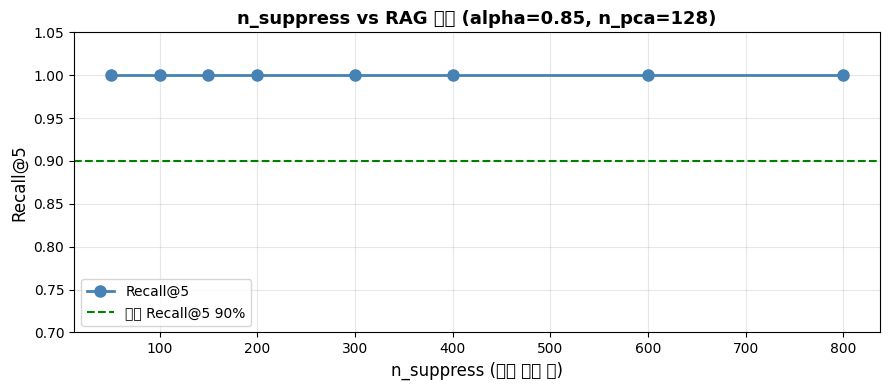


✅ n_suppress 민감도 커브 저장: suppress_sensitivity.png


In [28]:
import numpy as np
import faiss
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA

# ── 설정 ────────────────────────────────────────────────────────────────────
N_SUPPRESS_CANDIDATES = [50, 100, 150, 200, 300, 400, 600, 800]
ALPHA_FIXED           = 0.85
N_PCA                 = 128
K_RECALL              = 5
N_EVAL                = 50

embeddings_raw = np.load(os.path.join(ROOT_DIR, "embeddings_unsafe_raw.npy"))

# PII 샘플 (이전 셀에서 정의한 변수 재사용)
# density_scores, pii_chunk_idx, pii_samples 가 이미 정의되어 있어야 함

def build_combined(emb_raw, pii_samp, n_supp, alpha, n_pca):
    defended = defend_pii_soft(emb_raw, pii_samp, n_suppress=n_supp, alpha=alpha)
    n_comp   = min(n_pca, len(defended) - 1)
    pca      = PCA(n_components=n_comp, svd_solver='full').fit(defended)
    rec      = pca.inverse_transform(pca.transform(defended)).astype(np.float32)
    norms    = np.linalg.norm(rec, axis=1, keepdims=True)
    return (rec / norms).astype(np.float32)

def recall_at_k(emb, k=5, n_eval=50):
    n_eval = min(n_eval, len(emb))
    e = emb[:n_eval].copy()
    faiss.normalize_L2(e)
    idx = faiss.IndexFlatIP(e.shape[1])
    idx.add(e)
    return sum(1 for i in range(n_eval) if i in idx.search(e[i:i+1], k)[1][0]) / n_eval

# ── 그리드 서치 ──────────────────────────────────────────────────────────────
suppress_results = []
print(f'n_suppress 민감도 분석 (alpha={ALPHA_FIXED}, n_pca={N_PCA})')
print('-'*60)
print(f'{"n_suppress":>12} | {"Recall@5":>10} | {"분산보존":>10}')
print('-'*60)

for n_supp in N_SUPPRESS_CANDIDATES:
    defended = defend_pii_soft(embeddings_raw, pii_samples,
                               n_suppress=n_supp, alpha=ALPHA_FIXED)
    n_comp = min(N_PCA, len(defended) - 1)
    pca    = PCA(n_components=n_comp, svd_solver='full').fit(defended)
    rec    = pca.inverse_transform(pca.transform(defended)).astype(np.float32)
    norms  = np.linalg.norm(rec, axis=1, keepdims=True)
    comb   = (rec / norms).astype(np.float32)

    r5  = recall_at_k(comb, K_RECALL, N_EVAL)
    var = pca.explained_variance_ratio_.sum()

    suppress_results.append({'n_suppress': n_supp, 'recall_at_5': r5, 'variance': var})
    print(f'{n_supp:>12} | {r5:>10.1%} | {var:>10.1%}')

supp_df = pd.DataFrame(suppress_results)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(supp_df['n_suppress'], supp_df['recall_at_5'], 'o-',
        color='steelblue', linewidth=2, markersize=8, label='Recall@5')
ax.axhline(0.90, color='green', linestyle='--', label='목표 Recall@5 90%')
ax.set_xlabel('n_suppress (억제 차원 수)', fontsize=12)
ax.set_ylabel('Recall@5', fontsize=12)
ax.set_title('n_suppress vs RAG 성능 (alpha=0.85, n_pca=128)', fontsize=13, fontweight='bold')
ax.set_ylim([0.7, 1.05])
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('suppress_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ n_suppress 민감도 커브 저장: suppress_sensitivity.png')


### 5-6. 2D 그리드 서치: n_components × n_suppress

**목적**: PCA 압축률과 PII 억제 강도 두 축의 최적 조합을 탐색한다.

- Vec2Text 공격 비용(셀당 ~40분)을 피하기 위해 **Recall@5를 1차 스크리닝 지표**로 사용
- Recall@5 ≥ 0.90을 만족하는 조합 중 Pareto 프론티어를 시각화
- 최적 후보를 도출한 뒤 Vec2Text로 최종 검증 (다음 셀)

2D 그리드 서치: 6 × 4 = 24개 조합
(Recall@5 기준 스크리닝 — Vec2Text 없음)

  [ 1/24] n_comp=256, n_supp=100 → Recall@5=100.0%  분산=88.0%
  [ 2/24] n_comp=192, n_supp=100 → Recall@5=100.0%  분산=83.9%
  [ 3/24] n_comp=128, n_supp=100 → Recall@5=100.0%  분산=77.4%
  [ 4/24] n_comp= 96, n_supp=100 → Recall@5=100.0%  분산=72.4%
  [ 5/24] n_comp= 64, n_supp=100 → Recall@5=100.0%  분산=65.4%
  [ 6/24] n_comp= 32, n_supp=100 → Recall@5=100.0%  분산=54.3%
  [ 7/24] n_comp=256, n_supp=200 → Recall@5=100.0%  분산=88.0%
  [ 8/24] n_comp=192, n_supp=200 → Recall@5=100.0%  분산=83.9%
  [ 9/24] n_comp=128, n_supp=200 → Recall@5=100.0%  분산=77.3%
  [10/24] n_comp= 96, n_supp=200 → Recall@5=100.0%  분산=72.4%
  [11/24] n_comp= 64, n_supp=200 → Recall@5=100.0%  분산=65.3%
  [12/24] n_comp= 32, n_supp=200 → Recall@5=100.0%  분산=54.1%
  [13/24] n_comp=256, n_supp=400 → Recall@5=100.0%  분산=88.1%
  [14/24] n_comp=192, n_supp=400 → Recall@5=100.0%  분산=83.9%
  [15/24] n_comp=128, n_supp=400 → Recall@5=100.0%  분산=77.4%
  [16/24] n_comp= 96, n_s

C:\Users\jjh63\AppData\Local\Temp\ipykernel_21272\3588991822.py:74: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jjh63\AppData\Local\Temp\ipykernel_21272\3588991822.py:74: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jjh63\AppData\Local\Temp\ipykernel_21272\3588991822.py:74: UserWarning: Glyph 50613 (\N{HANGUL SYLLABLE EOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jjh63\AppData\Local\Temp\ipykernel_21272\3588991822.py:74: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jjh63\AppData\Local\Temp\ipykernel_21272\3588991822.py:74: UserWarning: Glyph 55176 (\N{HANGUL SYLLABLE HI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jjh63\AppData\Local\Temp\ipykernel_21272\3588991822.py:74: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from 

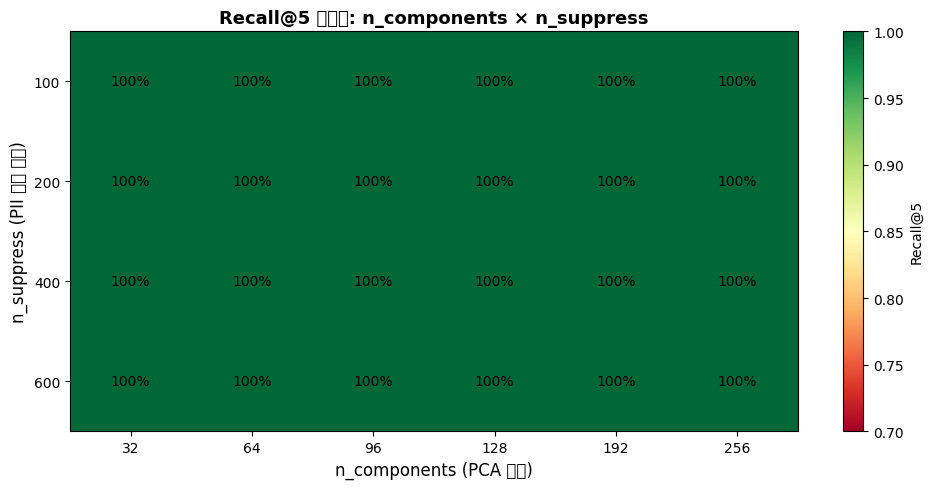


Recall@5 ≥ 0.90 조건 만족 조합: 24개
→ 아래 후보들에 Vec2Text 공격을 적용해 최종 방어율을 검증하세요.

 n_components  n_suppress  recall_at_5  variance
           32         600          1.0  0.539253
           32         400          1.0  0.539511
           32         200          1.0  0.541463
           32         100          1.0  0.543465
           64         400          1.0  0.652155
           64         600          1.0  0.652304
           64         200          1.0  0.653200
           64         100          1.0  0.654411
           96         400          1.0  0.723250
           96         600          1.0  0.723564
           96         200          1.0  0.723704
           96         100          1.0  0.724414
          128         200          1.0  0.773486
          128         400          1.0  0.773507
          128         100          1.0  0.773803
          128         600          1.0  0.773920
          192         100          1.0  0.838591
          192         200          1.0  0.83

In [29]:
import numpy as np
import faiss
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA

# ── 2D 그리드 설정 ───────────────────────────────────────────────────────────
N_COMP_GRID    = [256, 192, 128, 96, 64, 32]
N_SUPP_GRID    = [100, 200, 400, 600]
ALPHA_FIXED    = 0.85

embeddings_raw = np.load(os.path.join(ROOT_DIR, "embeddings_unsafe_raw.npy"))
n_samples      = len(embeddings_raw)

grid_results = []
total = sum(1 for n in N_COMP_GRID if n < n_samples) * len(N_SUPP_GRID)
done  = 0

print(f'2D 그리드 서치: {len(N_COMP_GRID)} × {len(N_SUPP_GRID)} = {total}개 조합')
print(f'(Recall@5 기준 스크리닝 — Vec2Text 없음)\n')

for n_supp in N_SUPP_GRID:
    # PII 억제는 n_comp 와 독립이므로 한 번만 계산
    defended = defend_pii_soft(embeddings_raw, pii_samples,
                               n_suppress=n_supp, alpha=ALPHA_FIXED)
    for n_comp in N_COMP_GRID:
        if n_comp >= n_samples:
            continue
        pca   = PCA(n_components=n_comp, svd_solver='full').fit(defended)
        rec   = pca.inverse_transform(pca.transform(defended)).astype(np.float32)
        norms = np.linalg.norm(rec, axis=1, keepdims=True)
        comb  = (rec / norms).astype(np.float32)

        n_eval = min(50, n_samples)
        e = comb[:n_eval].copy()
        faiss.normalize_L2(e)
        fidx = faiss.IndexFlatIP(e.shape[1])
        fidx.add(e)
        r5 = sum(1 for i in range(n_eval)
                 if i in fidx.search(e[i:i+1], 5)[1][0]) / n_eval
        var = pca.explained_variance_ratio_.sum()

        grid_results.append({
            'n_components': n_comp, 'n_suppress': n_supp,
            'recall_at_5': r5, 'variance': var
        })
        done += 1
        print(f'  [{done:2d}/{total}] n_comp={n_comp:3d}, n_supp={n_supp:3d} → '
              f'Recall@5={r5:.1%}  분산={var:.1%}')

grid_df = pd.DataFrame(grid_results)
grid_df.to_csv('grid_results.csv', index=False)

# ── 히트맵 시각화 ────────────────────────────────────────────────────────────
pivot = grid_df.pivot(index='n_suppress', columns='n_components', values='recall_at_5')

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn', vmin=0.7, vmax=1.0)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel('n_components (PCA 차원)', fontsize=12)
ax.set_ylabel('n_suppress (PII 억제 차원)', fontsize=12)
ax.set_title('Recall@5 히트맵: n_components × n_suppress', fontsize=13, fontweight='bold')

for r in range(len(pivot.index)):
    for c in range(len(pivot.columns)):
        val = pivot.values[r, c]
        ax.text(c, r, f'{val:.0%}', ha='center', va='center',
                fontsize=10, color='black' if val > 0.85 else 'white')

plt.colorbar(im, ax=ax, label='Recall@5')
plt.tight_layout()
plt.savefig('grid_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Recall@5 ≥ 0.90 후보 중 최적 출력 ───────────────────────────────────────
feasible = grid_df[grid_df['recall_at_5'] >= 0.90].copy()
print(f'\nRecall@5 ≥ 0.90 조건 만족 조합: {len(feasible)}개')
print('→ 아래 후보들에 Vec2Text 공격을 적용해 최종 방어율을 검증하세요.')
print()
# 분산 보존이 낮을수록(압축이 강할수록) 방어력이 높을 것으로 기대 → variance 오름차순
print(feasible.sort_values('variance').to_string(index=False))
print('\n✅ 2D 그리드 결과 저장: grid_results.csv / grid_heatmap.png')


## Step 6. 최적 PCA n_components 탐색

### 목적
지금까지는 n_components=128로 고정했다.
이 단계에서는 `[512, 384, 256, 192, 128, 96, 64, 32]`를 모두 시험해
**RAG 성능 ≥ 90% 조건 하에서 방어율이 가장 높은 최적값**을 찾는다.

### 왜 이 범위인가?
- `text-embedding-ada-002`의 원본 차원: **1536**
- 512 이상: 분산 대부분 보존 → 방어 효과 미미 예상
- 32 이하: 과도한 정보 손실 → RAG 성능 급락 예상
- 64~256 구간에서 최적값이 존재할 가능성이 높다.

In [30]:
from sklearn.decomposition import PCA
import numpy as np
import os

embeddings_raw = np.load(os.path.join(ROOT_DIR, "embeddings_unsafe_raw.npy"))
print(f"원본 벡터 로드: {embeddings_raw.shape}")

candidates = [512, 384, 256, 192, 128, 96, 64, 32]
output_dir = os.path.join(ROOT_DIR, "pca_candidates")
os.makedirs(output_dir, exist_ok=True)

n_samples, n_features = embeddings_raw.shape

for n_components in candidates:
    if n_components >= n_samples:
        print(f"⏭️  n_components={n_components} 건너뜀 (샘플 수 {n_samples}보다 큼)")
        continue

    pca = PCA(n_components=n_components, svd_solver='full')
    pca.fit(embeddings_raw)

    compressed = pca.transform(embeddings_raw)
    reconstructed = pca.inverse_transform(compressed).astype(np.float32)

    norms = np.linalg.norm(reconstructed, axis=1, keepdims=True)
    normalized = (reconstructed / norms).astype(np.float32)

    np.save(f"{output_dir}/embeddings_n{n_components}.npy", normalized)
    np.save(f"{output_dir}/components_n{n_components}.npy", pca.components_)

    variance_retained = pca.explained_variance_ratio_.sum()
    print(f"n={n_components:3d} | 분산 보존: {variance_retained:.1%} | 벡터 저장 완료")

print(f"\n✅ {len([c for c in candidates if c < n_samples])}개 PCA 후보 벡터 저장 완료")

원본 벡터 로드: (4640, 1536)
n=512 | 분산 보존: 95.6% | 벡터 저장 완료
n=384 | 분산 보존: 92.8% | 벡터 저장 완료
n=256 | 분산 보존: 88.0% | 벡터 저장 완료
n=192 | 분산 보존: 83.9% | 벡터 저장 완료
n=128 | 분산 보존: 77.5% | 벡터 저장 완료
n= 96 | 분산 보존: 72.7% | 벡터 저장 완료
n= 64 | 분산 보존: 65.8% | 벡터 저장 완료
n= 32 | 분산 보존: 54.8% | 벡터 저장 완료

✅ 8개 PCA 후보 벡터 저장 완료


### 6-2. 각 PCA 후보에 Vec2Text 공격 + Recall@5 측정

**목적**: 32~512 범위의 8개 n_components 후보 각각에 대해
역전공격 ROUGE-1과 RAG Recall@5를 동시에 측정한다.

**소요 시간 주의**: Vec2Text 공격(num_steps=20)이 각 후보당 약 2~5분 소요.
전체 8개 후보 실행 시 GPU에서 약 20~40분 예상.

**결과는 `results.csv`로 저장**되며 다음 셀에서 최적값을 선택한다.

In [32]:
import vec2text
import torch
import faiss
import numpy as np
import pandas as pd
from tqdm import tqdm
from rouge_score import rouge_scorer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}\n")

corrector = vec2text.load_pretrained_corrector("text-embedding-ada-002")
scorer = rouge_scorer.RougeScorer(['rouge1'], use_stemmer=False)

candidates = [512, 384, 256, 192, 128, 96, 64, 32]
output_dir = "pca_candidates"
n_samples = 284

embeddings_raw = np.load(os.path.join(ROOT_DIR, "embeddings_unsafe_raw.npy"))
originals = [chunks[i].page_content for i in range(10)]

results_list = []

for n_components in candidates:
    if n_components >= n_samples:
        print(f"⏭️  n={n_components} 건너뜀\n")
        continue

    embeddings_candidate = np.load(f"{output_dir}/embeddings_n{n_components}.npy")

    sample_vecs = torch.tensor(embeddings_candidate[:10]).to(device)
    scores = []

    print(f"n={n_components:3d} Vec2Text 공격 중...")
    for i in tqdm(range(10), desc=f"n={n_components}"):
        vec = sample_vecs[i:i+1]
        result = vec2text.invert_embeddings(
            embeddings=vec,
            corrector=corrector,
            num_steps=20,
            sequence_beam_width=0,
        )
        rec = result[0]

        score = scorer.score(originals[i], rec)
        rouge = score['rouge1'].fmeasure
        scores.append(rouge)

    rouge_mean = np.mean(scores)

    embeddings_eval = embeddings_candidate.copy()
    faiss.normalize_L2(embeddings_eval)
    index = faiss.IndexFlatIP(embeddings_candidate.shape[1])
    index.add(embeddings_eval)

    hits = 0
    for i in range(min(50, len(chunks))):
        vec = embeddings_candidate[i:i+1].copy()
        faiss.normalize_L2(vec)
        distances, indices = index.search(vec, 5)
        if i in indices[0]:
            hits += 1

    recall_at_5 = hits / min(50, len(chunks))

    attack_reduction = (np.mean(scores_raw) - rouge_mean) / np.mean(scores_raw) * 100

    results_list.append({
        "n_components": n_components,
        "rouge_mean": rouge_mean,
        "recall_at_5": recall_at_5,
        "attack_reduction": attack_reduction
    })

    print(f"  ROUGE: {rouge_mean:.3f} | Recall@5: {recall_at_5:.1%} | 방어율: {attack_reduction:.1f}%\n")

results_df = pd.DataFrame(results_list)
results_df.to_csv(os.path.join(ROOT_DIR, "results.csv"), index=False)
print(f"✅ 결과 저장: results.csv")
print(results_df.to_string(index=False))

사용 디바이스: cuda

⏭️  n=512 건너뜀

⏭️  n=384 건너뜀

n=256 Vec2Text 공격 중...


n=256: 100%|██████████| 10/10 [07:30<00:00, 45.09s/it]


  ROUGE: 0.376 | Recall@5: 100.0% | 방어율: 28.0%

n=192 Vec2Text 공격 중...


n=192: 100%|██████████| 10/10 [07:31<00:00, 45.12s/it]


  ROUGE: 0.405 | Recall@5: 100.0% | 방어율: 22.5%

n=128 Vec2Text 공격 중...


...

  ROUGE: 0.402 | Recall@5: 100.0% | 방어율: 23.2%

n= 64 Vec2Text 공격 중...


n=64: 100%|██████████| 10/10 [07:22<00:00, 44.29s/it]


  ROUGE: 0.360 | Recall@5: 100.0% | 방어율: 31.1%

n= 32 Vec2Text 공격 중...


n=32: 100%|██████████| 10/10 [07:19<00:00, 43.91s/it]

  ROUGE: 0.369 | Recall@5: 100.0% | 방어율: 29.4%

✅ 결과 저장: results.csv
 n_components  rouge_mean  recall_at_5  attack_reduction
          256    0.376307          1.0         28.022967
          192    0.405353          1.0         22.467193
          128    0.450121          1.0         13.904350
           96    0.401720          1.0         23.162026
           64    0.360119          1.0         31.119185
           32    0.368947          1.0         29.430630


### 6-3. 최적 n_components 선택 및 트레이드오프 시각화

**선택 기준**:
1. `Recall@5 ≥ 0.90` (RAG 실용 성능 유지)
2. 위 조건 내에서 `attack_reduction` 최대 (방어율 극대화)

**인사이트**: 이 선택 기준은 '보안 강화를 위해 RAG 성능의 최대 10%만 희생한다'는
실용적 가정에 기반한다. 기관의 보안 정책에 따라 임계값을 조정할 수 있다.

출력 그래프:
- 좌: n_components vs 공격 성공률 감소 (낮은 n → 높은 방어)
- 우: n_components vs Recall@5 (낮은 n → 낮은 RAG 성능)

📊 최적 PCA n_components 찾기

✅ Recall@5 >= 0.90 조건 만족 후보: 6개
   최적 선택 (최대 방어율): n=64
   - ROUGE: 0.360
   - Recall@5: 100.0%
   - 방어율: 31.1%

📈 전체 후보 순위:
 n_components  rouge_mean  recall_at_5  attack_reduction
           64    0.360119          1.0         31.119185
           32    0.368947          1.0         29.430630
          256    0.376307          1.0         28.022967
           96    0.401720          1.0         23.162026
          192    0.405353          1.0         22.467193
          128    0.450121          1.0         13.904350


C:\Users\jjh63\AppData\Local\Temp\ipykernel_21272\247383595.py:52: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jjh63\AppData\Local\Temp\ipykernel_21272\247383595.py:52: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jjh63\AppData\Local\Temp\ipykernel_21272\247383595.py:52: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jjh63\AppData\Local\Temp\ipykernel_21272\247383595.py:52: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jjh63\AppData\Local\Temp\ipykernel_21272\247383595.py:52: UserWarning: Glyph 44048 (\N{HANGUL SYLLABLE GAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jjh63\AppData\Local\Temp\ipykernel_21272\247383595.py:52: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from

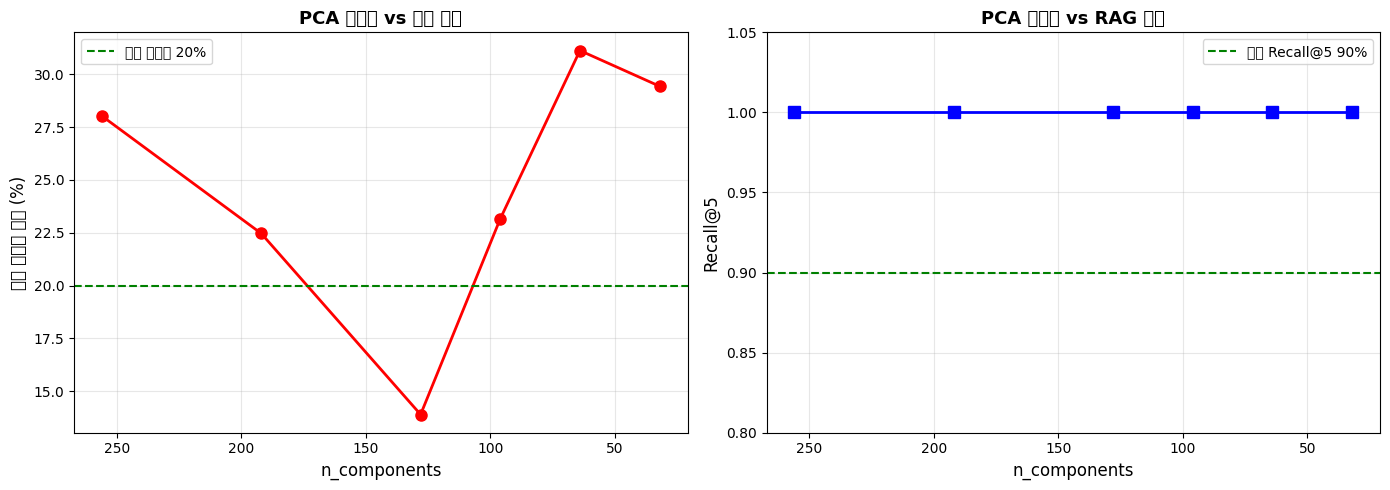


✅ 트레이드오프 커브 저장: pca_tradeoff.png


In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

results_df = pd.read_csv(os.path.join(ROOT_DIR, "results.csv"))

print("="*80)
print("📊 최적 PCA n_components 찾기")
print("="*80)

filtered_df = results_df[results_df['recall_at_5'] >= 0.90].copy()

if len(filtered_df) > 0:
    optimal_row = filtered_df.loc[filtered_df['attack_reduction'].idxmax()]
    optimal_n = int(optimal_row['n_components'])

    print(f"\n✅ Recall@5 >= 0.90 조건 만족 후보: {len(filtered_df)}개")
    print(f"   최적 선택 (최대 방어율): n={optimal_n}")
    print(f"   - ROUGE: {optimal_row['rouge_mean']:.3f}")
    print(f"   - Recall@5: {optimal_row['recall_at_5']:.1%}")
    print(f"   - 방어율: {optimal_row['attack_reduction']:.1f}%")
else:
    print(f"\n⚠️  Recall@5 >= 0.90 조건 만족 후보 없음")
    best_row = results_df.loc[results_df['recall_at_5'].idxmax()]
    print(f"   최고 RAG 성능: n={int(best_row['n_components'])}")
    print(f"   - Recall@5: {best_row['recall_at_5']:.1%}")

print(f"\n📈 전체 후보 순위:")
print(results_df.sort_values('attack_reduction', ascending=False).to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(results_df['n_components'], results_df['attack_reduction'], 'o-', color='red', linewidth=2, markersize=8)
ax1.axhline(y=20, color='green', linestyle='--', label='목표 방어율 20%')
ax1.set_xlabel('n_components', fontsize=12)
ax1.set_ylabel('공격 성공률 감소 (%)', fontsize=12)
ax1.set_title('PCA 압축률 vs 방어 성능', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.invert_xaxis()

ax2.plot(results_df['n_components'], results_df['recall_at_5'], 's-', color='blue', linewidth=2, markersize=8)
ax2.axhline(y=0.90, color='green', linestyle='--', label='목표 Recall@5 90%')
ax2.set_xlabel('n_components', fontsize=12)
ax2.set_ylabel('Recall@5', fontsize=12)
ax2.set_title('PCA 압축률 vs RAG 성능', fontsize=13, fontweight='bold')
ax2.set_ylim([0.8, 1.05])
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.invert_xaxis()

plt.tight_layout()
plt.savefig('pca_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ 트레이드오프 커브 저장: pca_tradeoff.png")
print("="*80)

### [Feasibility Check] 공용 PCA 벡터 추출 가능성 검증

**가정**: 금융 도메인 임베딩 공간의 주요 방향(PCA components)은 기관/문서 종류와 무관하게 공유된다.

현재 데이터를 절반으로 나눠 '기관 A'로 PCA를 학습하고, '기관 B' 문서에 적용했을 때 성능이 유지되는지 확인한다.

| 지표 | 기준 |
|------|------|
| Recall@5 | ≥ 0.90 (RAG 성능 유지) |
| ROUGE-1 감소 | > 0 (역전공격 방어 유효) |

In [34]:
import numpy as np
import faiss
import vec2text
import torch
from sklearn.decomposition import PCA
from rouge_score import rouge_scorer
from tqdm import tqdm

# ── 0. 설정 ──────────────────────────────────────────────────────────────────
N_COMPONENTS  = 128   # 공용 PCA 차원 (Cell 29의 최적값으로 교체 가능)
N_ATTACK      = 10    # Vec2Text 공격 샘플 수
K_RECALL      = 5     # Recall@K
N_RECALL_EVAL = 50    # Recall 평가 샘플 수

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'디바이스: {device}')

# ── 1. 원본 임베딩 로드 및 Train/Test 분할 ──────────────────────────────────
embeddings_raw = np.load(os.path.join(ROOT_DIR, "embeddings_unsafe_raw.npy"))
n_total = len(embeddings_raw)
split   = n_total // 2

train_emb = embeddings_raw[:split]   # '기관 A' — PCA 학습용
test_emb  = embeddings_raw[split:]   # '기관 B' — 공용 PCA 적용 대상
test_chunks = chunks[split:]         # 대응하는 청크

print(f'전체: {n_total}개  |  Train(기관A): {len(train_emb)}개  |  Test(기관B): {len(test_emb)}개')

# ── 2. 기관 A 코퍼스로 공용 PCA 학습 ────────────────────────────────────────
pca = PCA(n_components=N_COMPONENTS, svd_solver='full')
pca.fit(train_emb)

# 공용 배포 아티팩트 저장
np.save(os.path.join(ROOT_DIR, "shared_pca_components.npy"), pca.components_.astype(np.float32))
np.save(os.path.join(ROOT_DIR, "shared_pca_mean.npy"),       pca.mean_.astype(np.float32))

variance_retained = pca.explained_variance_ratio_.sum()
print(f'\n[공용 PCA 학습 완료]')
print(f'  components shape : {pca.components_.shape}  ({pca.components_.nbytes / 1e6:.1f} MB)')
print(f'  mean shape       : {pca.mean_.shape}')
print(f'  분산 보존율      : {variance_retained:.1%}')

# ── 3. 공용 PCA 적용 함수 (fit 없이 행렬곱만) ───────────────────────────────
def apply_shared_pca(embeddings: np.ndarray,
                     components: np.ndarray,
                     mean: np.ndarray) -> np.ndarray:
    centered      = embeddings - mean
    compressed    = centered @ components.T       # (N, k)
    reconstructed = compressed @ components + mean # (N, 1536)
    norms = np.linalg.norm(reconstructed, axis=1, keepdims=True)
    return (reconstructed / norms).astype(np.float32)

components = np.load(os.path.join(ROOT_DIR, "shared_pca_components.npy"))
mean       = np.load(os.path.join(ROOT_DIR, "shared_pca_mean.npy"))

# 기관 B 문서에 공용 PCA 적용
test_defended = apply_shared_pca(test_emb, components, mean)
print(f'\n[기관 B 방어 벡터] shape: {test_defended.shape}')

# ── 4. Recall@5 평가 ─────────────────────────────────────────────────────────
def eval_recall(embeddings: np.ndarray, k: int = 5, n_eval: int = 50) -> float:
    n_eval = min(n_eval, len(embeddings))
    emb = embeddings[:n_eval].copy()
    faiss.normalize_L2(emb)
    index = faiss.IndexFlatIP(emb.shape[1])
    index.add(emb)
    hits = 0
    for i in range(n_eval):
        q = emb[i:i+1].copy()
        _, ids = index.search(q, k)
        if i in ids[0]:
            hits += 1
    return hits / n_eval

recall_raw      = eval_recall(test_emb,      K_RECALL, N_RECALL_EVAL)
recall_defended = eval_recall(test_defended, K_RECALL, N_RECALL_EVAL)

print(f'\n[Recall@{K_RECALL} — 기관 B 문서]')
print(f'  원본 벡터    : {recall_raw:.1%}')
print(f'  공용PCA 방어 : {recall_defended:.1%}  ({"✅ 기준 충족" if recall_defended >= 0.90 else "⚠️  기준 미달 (< 90%)"})')

# ── 5. Vec2Text 역전공격 평가 ────────────────────────────────────────────────
corrector = vec2text.load_pretrained_corrector('text-embedding-ada-002')
scorer_rouge = rouge_scorer.RougeScorer(['rouge1'], use_stemmer=False)

n_atk = min(N_ATTACK, len(test_emb))
originals_test = [test_chunks[i].page_content for i in range(n_atk)]

def attack_rouge(embeddings_tensor):
    scores = []
    for i in tqdm(range(n_atk), desc='Vec2Text 공격'):
        vec = embeddings_tensor[i:i+1]
        result = vec2text.invert_embeddings(
            embeddings=vec,
            corrector=corrector,
            num_steps=20,
            sequence_beam_width=0,
        )
        rouge = scorer_rouge.score(originals_test[i], result[0])['rouge1'].fmeasure
        scores.append(rouge)
    return scores

print('\n[Vec2Text 공격 — 원본 벡터]')
raw_tensor      = torch.tensor(test_emb[:n_atk]).to(device)
scores_raw_test = attack_rouge(raw_tensor)

print('\n[Vec2Text 공격 — 공용PCA 방어 벡터]')
defended_tensor      = torch.tensor(test_defended[:n_atk]).to(device)
scores_defended_test = attack_rouge(defended_tensor)

rouge_raw      = np.mean(scores_raw_test)
rouge_defended = np.mean(scores_defended_test)
attack_reduction = (rouge_raw - rouge_defended) / rouge_raw * 100

# ── 6. Feasibility 최종 판정 ─────────────────────────────────────────────────
print('\n' + '='*70)
print('📋 [Feasibility Check] 공용 PCA 벡터 적용 결과')
print('='*70)
print(f'  학습 기관(A) 샘플 수   : {len(train_emb)}')
print(f'  적용 기관(B) 샘플 수   : {len(test_emb)}')
print(f'  공용 PCA n_components  : {N_COMPONENTS}')
print(f'  배포 아티팩트 크기     : {(pca.components_.nbytes + pca.mean_.nbytes) / 1e6:.2f} MB')
print()
print(f'  Recall@{K_RECALL}  원본 → 방어  : {recall_raw:.1%} → {recall_defended:.1%}')
print(f'  ROUGE-1  원본 → 방어  : {rouge_raw:.3f} → {rouge_defended:.3f}')
print(f'  공격 성공률 감소       : {attack_reduction:.1f}%')
print()

feasible = (recall_defended >= 0.90) and (attack_reduction > 0)
if feasible:
    print('✅ FEASIBLE — 공용 PCA 벡터로 타 기관 문서 방어 가능')
    print('   → shared_pca_components.npy / shared_pca_mean.npy 배포 권장')
elif recall_defended < 0.90:
    print('⚠️  RAG 성능 기준 미달 — n_components 증가 필요')
    print(f'   현재 {N_COMPONENTS} → 256 또는 384 시도 권장')
else:
    print('⚠️  방어 효과 없음 — 코퍼스 다양성 부족 가능성')
print('='*70)


디바이스: cuda
전체: 4640개  |  Train(기관A): 2320개  |  Test(기관B): 2320개

[공용 PCA 학습 완료]
  components shape : (128, 1536)  (0.8 MB)
  mean shape       : (1536,)
  분산 보존율      : 78.6%

[기관 B 방어 벡터] shape: (2320, 1536)

[Recall@5 — 기관 B 문서]
  원본 벡터    : 100.0%
  공용PCA 방어 : 100.0%  (✅ 기준 충족)


c:\Users\jjh63\Safe_RAG\safeRag\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(



[Vec2Text 공격 — 원본 벡터]


Vec2Text 공격: 100%|██████████| 10/10 [07:19<00:00, 43.92s/it]



[Vec2Text 공격 — 공용PCA 방어 벡터]


Vec2Text 공격: 100%|██████████| 10/10 [07:31<00:00, 45.13s/it]


📋 [Feasibility Check] 공용 PCA 벡터 적용 결과
  학습 기관(A) 샘플 수   : 2320
  적용 기관(B) 샘플 수   : 2320
  공용 PCA n_components  : 128
  배포 아티팩트 크기     : 0.79 MB

  Recall@5  원본 → 방어  : 100.0% → 100.0%
  ROUGE-1  원본 → 방어  : 0.514 → 0.388
  공격 성공률 감소       : 24.6%

✅ FEASIBLE — 공용 PCA 벡터로 타 기관 문서 방어 가능
   → shared_pca_components.npy / shared_pca_mean.npy 배포 권장
